# Selección, extracción y normalización de características

Este notebook responde una pregunta concreta: dada una matriz de
características espectro-temporales por parcela, ¿qué subconjunto y qué
transformación preservan la señal agronómica con la mínima dimensionalidad
para alimentar modelos tabulares y redes neuronales?

El pipeline cubre vista del dataset por familia agronómica, balance de
clases, filtros estadísticos (varianza + correlación de Pearson con
análisis por familia), tests univariados (chi-cuadrado + ANOVA F),
extractores no supervisados (PCA con interpretación de loadings + Factor
Analysis + UMAP), ranking supervisado (Random Forest + XGBoost) con
importancia agregada por familia, tabla consenso multi-criterio,
comparativa F1-macro y mIoU antes/después sobre folds espaciales
oficiales, y decisiones de escalamiento encapsuladas en un
`ColumnTransformer` serializable. Cierra persistiendo el frame
filtrado y la lista de features finales en `reports/feature_selection/`.

## Requisitos para ejecución end-to-end

- `poetry install --with ml,dev,test` ejecutado.
- Subset `data/test_fixtures/feature_selection_subset.parquet` presente
  (139 KB, generado por `make feature-selection-subset`). Si no existe,
  el notebook genera un sustituto sintético equivalente y completa la
  ejecución sin error.

Secciones:

1. Setup y carga (real o sintética auto-detectada)
2. Vista del dataset por familia agronómica
3. Balance de clases y muestras por categoría
4. Filtros (umbral de varianza + correlación de Pearson) con análisis por familia
5. Tests univariados (chi-cuadrado + ANOVA F)
6. Extractores no supervisados (PCA + loadings interpretados + Factor Analysis + UMAP 2D)
7. Importancia supervisada (Random Forest + XGBoost) agregada por familia
8. Tabla consenso multi-criterio de features
9. Comparativa antes/después y decisiones de normalización
10. Persistencia del frame filtrado y conclusiones


## 1. Setup y carga del subset

In [1]:
from __future__ import annotations

import os
os.environ.setdefault('MPLBACKEND', 'Agg')

import json
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import structlog
from IPython.display import Image, Markdown, display

from ml.utils.notebook_setup import find_repo_root

REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

from ml.features.selection import (
    anova_f_select,
    apply_variance_threshold,
    chi2_select,
    compare_before_after,
    compute_feature_importance,
    drop_correlated_features,
    fit_factor_analysis,
    fit_pca,
    fit_umap_2d,
    make_preprocessor,
    select_normalizer,
)
from ml.features.selection import _load_pastis_features_subset  # type: ignore[reportPrivateUsage]

%load_ext autoreload
%autoreload 2

pl.Config.set_tbl_formatting('ASCII_MARKDOWN')
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(60)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200

log = structlog.get_logger('fe_selection')

REPORTS_DIR = REPO_ROOT / 'reports' / 'feature_selection'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SUBSET_PARQUET = REPO_ROOT / 'data' / 'test_fixtures' / 'feature_selection_subset.parquet'
display(Markdown(f'**Subset esperado**: `{SUBSET_PARQUET.relative_to(REPO_ROOT)}` (existe: `{SUBSET_PARQUET.exists()}`)'))


**Subset esperado**: `data\test_fixtures\feature_selection_subset.parquet` (existe: `True`)

In [2]:
# Carga automatica: parquet real si existe, sintetico equivalente si no.
MODE = 'real' if SUBSET_PARQUET.exists() else 'synthetic'

if MODE == 'real':
    X, y, folds = _load_pastis_features_subset(SUBSET_PARQUET)
else:
    from tests.ml.features.fixtures.selection_synthetic import make_pastis_subset_synthetic
    X, y, folds = make_pastis_subset_synthetic(
        n_samples=500, n_features=187, n_classes=20, seed=42
    )

display(Markdown(
    f'**Modo de carga**: `{MODE}` | **Forma**: `{X.shape[0]}` muestras x `{X.shape[1]}` columnas | '
    f'**Clases**: `{len(set(y.to_list()))}` | **Folds espaciales**: `{sorted(set(folds.tolist()))}`'
))
display(X.head(5))


**Modo de carga**: `real` | **Forma**: `77` muestras x `187` columnas | **Clases**: `17` | **Folds espaciales**: `[1, 2, 3, 4, 5]`

parcel_id,year,NDVI_mean,NDVI_std,NDVI_min,NDVI_max,NDVI_p05,NDVI_p25,NDVI_p50,NDVI_p75,NDVI_p95,NDWI_mean,NDWI_std,NDWI_min,NDWI_max,NDWI_p05,NDWI_p25,NDWI_p50,NDWI_p75,NDWI_p95,EVI_mean,EVI_std,EVI_min,EVI_max,EVI_p05,EVI_p25,EVI_p50,EVI_p75,EVI_p95,NDMI_mean,NDMI_std,NDMI_min,NDMI_max,NDMI_p05,NDMI_p25,NDMI_p50,NDMI_p75,…,TSAVI_p05,TSAVI_p25,TSAVI_p50,TSAVI_p75,TSAVI_p95,NDVI_fft_amp_0,NDVI_fft_phase_0,NDVI_fft_amp_1,NDVI_fft_phase_1,NDVI_fft_amp_2,NDVI_fft_phase_2,NDVI_fft_amp_3,NDVI_fft_phase_3,NDWI_fft_amp_0,NDWI_fft_phase_0,NDWI_fft_amp_1,NDWI_fft_phase_1,NDWI_fft_amp_2,NDWI_fft_phase_2,NDWI_fft_amp_3,NDWI_fft_phase_3,EVI_fft_amp_0,EVI_fft_phase_0,EVI_fft_amp_1,EVI_fft_phase_1,EVI_fft_amp_2,EVI_fft_phase_2,EVI_fft_amp_3,EVI_fft_phase_3,sog_doy,peak_doy,peak_value,senescence_doy,ndvi_auc,ndvi_slope_pre_peak,ndvi_slope_post_peak,maturity_duration_days
i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,i64,f64,f64,f64,i64
20324,2018,0.358485,0.10515,-0.0,0.538328,0.081484,0.341796,0.386067,0.407629,0.462055,-0.414918,0.115156,-0.542596,-0.0,-0.497702,-0.474893,-0.454249,-0.405135,-0.105126,0.24482,0.063623,0.0,0.327748,0.130417,0.216199,0.255841,0.289252,0.313552,0.037136,0.106294,-0.078474,0.57374,-0.04693,-0.004738,0.018757,0.03957,…,0.081484,0.341796,0.386067,0.407629,0.462055,0.35454,0.0,0.020367,0.182391,0.034651,3.114454,0.007251,2.168429,0.408553,0.0,0.01533,-1.748183,0.040371,-0.559519,0.007539,-0.936592,0.240039,0.0,0.035762,1.189931,0.016463,-3.005618,0.008153,0.111341,55,61,0.538328,69,143.507254,0.035488,-0.031992,7
30659,2018,0.526919,0.24137,-0.001981,0.823756,0.00939,0.496646,0.605407,0.700769,0.788994,-0.508338,0.221299,-0.732032,-0.005669,-0.719282,-0.663074,-0.593983,-0.469251,-0.022971,0.380826,0.153188,-0.007389,0.630876,0.048746,0.312056,0.372848,0.486616,0.613525,0.177599,0.105269,0.031397,0.410536,0.039394,0.089963,0.158312,0.233849,…,0.00939,0.496646,0.605407,0.700769,0.788994,0.477485,0.0,0.136726,1.856451,0.054345,-1.214417,0.080672,-0.681488,0.462103,0.0,0.115965,-1.267454,0.040524,2.009307,0.087386,2.31508,0.357933,0.0,0.130249,1.781357,0.067768,-0.702728,0.056236,-0.005463,48,246,0.823756,321,190.941672,0.001438,-0.003655,25
40303,2018,0.491702,0.257022,-0.005792,0.895872,0.0155,0.325236,0.426314,0.755793,0.872843,-0.511655,0.218572,-0.80217,0.078867,-0.788401,-0.694873,-0.501689,-0.417426,-0.034761,0.360711,0.225082,-0.005532,0.694159,0.060053,0.186093,0.289808,0.607727,0.688717,0.179054,0.239642,-0.189887,0.844295,-0.116595,-0.014566,0.125944,0.376814,…,0.0155,0.325236,0.426314,0.755793,0.872843,0.433141,0.0,0.236053,1.149887,0.098675,2.537058,0.084593,-2.274962,0.479962,0.0,0.149924,-1.999079,0.063852,-0.63931,0.102183,1.071777,0.288552,0.0,0.266813,1.264237,0.08629,2.330798,0.049637,-2.375297,119,346,0.895872,369,168.897492,0.002781,-0.025281,34
20320,2018,0.453226,0.145836,-0.02565,0.627523,0.128455,0.454293,0.491551,0.530532,0.586188,-0.480528,0.145783,-0.642826,-0.0,-0.625893,-0.559368,-0.523793,-0.495322,-0.136422,0.281168,0.071984,-0.030958,0.375041,0.151987,0.273367,0.29316,0.314174,0.367492,0.071109,0.139577,-0.063049,1.047879,-0.012782,0.015909,0.045462,0.087117,…,0.128455,0.454293,0.491551,0.530532,0.586188,0.439186,0.0,0.05296,-3.061113,0.104536,2.076312,0.043164,0.976186,0.466357,0.0,0.057735,0.085113,0.116517,-1.048479,0.030002,-2.114795,0.276664,0.0,0.037806,1.989059,0.020581,1.861171,0.024936,0.519388,55,81,0.627523,229,177.863141,-0.004572,-0.000888,19
40152,2018,0.499038,0.148463,-0.017869,0.669176,0.196713,0.473382,0.546585,0.586098,0.639221,-0.514856,0.149965,-0.655173,0.049934,-0.641677,-0.600844,-0.569502,-0.508503,-0.206274,0.329879,0.083505,-0.064202,0.445113,0.232102,0.30951,0.347604,0.369667,0.423891,0.108237,0.055055,-0.018797,0.263087,0.01377

## 2. Vista del dataset por familia agronómica

Las 187 columnas upstream no son una matriz numérica genérica: provienen
de 17 índices espectrales con interpretación fisiológica distinta
(NDVI clorofila, NDWI/NDMI agua, MSAVI2 suelo desnudo, NDRE/CCCI bordes
rojo, LAI/FAPAR estructura del dosel, NBR fuego, GCVI clorofila verde,
PSRI senescencia, EVI biomasa robusto, TSAVI ajustado al suelo). Cada
índice viene con 9 estadísticos temporales (mean/std/min/max + 5
percentiles), 3 índices llevan además 8 componentes FFT (amplitud y
fase del ciclo armónico) y la fenología derivada aporta 8 features de
trayectoria (`sog_doy`, `peak_doy`, `senescence_doy`, `ndvi_auc`,
pendientes pre/post pico, duración de madurez).

Esta vista anticipa qué *tipo* de información domina antes de aplicar
filtros estadísticos ciegos a la semántica.


In [3]:
# Clasificacion semantica de las 187 columnas en familias agronomicas.
AGRONOMIC_INDICES = (
    'NDVI', 'NDRE', 'NDWI', 'NDMI', 'NBR', 'MSAVI2', 'EVI', 'MCARI', 'CCCI',
    'GCVI', 'PSRI', 'NDCI', 'FAPAR', 'LAI', 'RENDVI', 'SAVI', 'TSAVI',
)
STAT_SUFFIXES = ('_mean', '_std', '_min', '_max', '_p05', '_p25', '_p50', '_p75', '_p95')
FFT_TOKEN = '_fft_'
PHENOLOGY_COLS = {
    'sog_doy', 'peak_doy', 'peak_value', 'senescence_doy',
    'ndvi_auc', 'ndvi_slope_pre_peak', 'ndvi_slope_post_peak',
    'maturity_duration_days',
}
META_COLS = {'parcel_id', 'year', 'fold', 'class_id'}

def classify_feature(col_name: str) -> tuple[str, str]:
    """Devuelve (familia_idx, kind) para una columna."""
    if col_name in META_COLS:
        return ('_meta', 'meta')
    if col_name in PHENOLOGY_COLS:
        return ('_phenology', 'phenology')
    if FFT_TOKEN in col_name:
        idx = col_name.split(FFT_TOKEN)[0]
        return (idx, 'fft')
    for idx in AGRONOMIC_INDICES:
        if col_name.startswith(idx + '_'):
            return (idx, 'stat')
    return ('_other', 'other')

feature_taxonomy = pl.DataFrame(
    [(c, *classify_feature(c)) for c in X.columns],
    schema=['feature', 'family', 'kind'],
    orient='row',
)
family_summary = (
    feature_taxonomy.filter(pl.col('family') != '_meta')
    .group_by(['family', 'kind'])
    .agg(pl.len().alias('n_cols'))
    .sort(['kind', 'family'])
)
totals_by_kind = feature_taxonomy.filter(pl.col('family') != '_meta').group_by('kind').agg(pl.len().alias('n')).sort('n', descending=True)
display(Markdown('**Distribución de columnas por tipo de feature**'))
display(totals_by_kind)
display(Markdown('**Detalle por familia agronómica e índice espectral**'))
display(family_summary)


**Distribución de columnas por tipo de feature**

kind,n
str,u32
"""stat""",153
"""fft""",24
"""phenology""",8


**Detalle por familia agronómica e índice espectral**

family,kind,n_cols
str,str,u32
"""EVI""","""fft""",8
"""NDVI""","""fft""",8
"""NDWI""","""fft""",8
"""_phenology""","""phenology""",8
"""CCCI""","""stat""",9
"""EVI""","""stat""",9
"""FAPAR""","""stat""",9
"""GCVI""","""stat""",9
"""LAI""","""stat""",9


## 3. Balance de clases y muestras por categoría

El subset estratifica 17 clases de cultivo, pero el balance no es
perfecto: clases minoritarias con 1 a 3 muestras condicionan los
rankings supervisados (Random Forest / XGBoost subajustan en
categorías con menos de 5 ejemplos) y limitan la confianza de
F1-macro en la comparativa antes/después. Lo dejamos visible aquí
antes de operar.


**Distribución de muestras por clase** (n=77 parcelas, 17 clases). Mín: `1`, mediana: `5`, máx: `5`.  
**Clases minoritarias (<5 muestras)**: `3` → rankings supervisados deben interpretarse con cautela en ellas.

class_id,n_samples
i64,u32
2,5
16,5
7,5
8,5
12,5
18,5
15,5
3,5
4,5


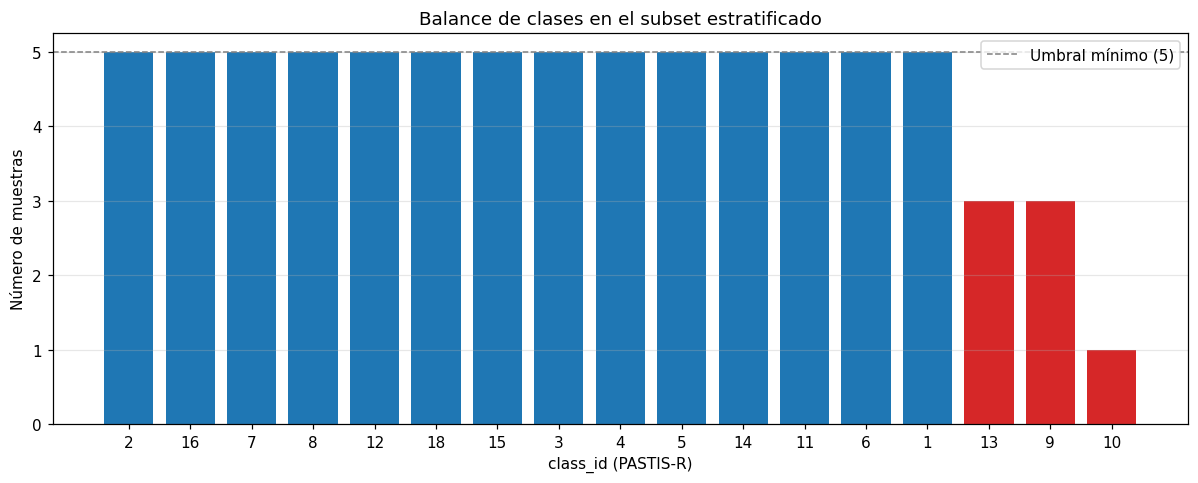

In [4]:
class_counts = (
    pl.DataFrame({'class_id': y.to_list()})
    .group_by('class_id')
    .agg(pl.len().alias('n_samples'))
    .sort('n_samples', descending=True)
)
min_n = int(class_counts['n_samples'].min())
max_n = int(class_counts['n_samples'].max())
median_n = float(class_counts['n_samples'].median())
minority = class_counts.filter(pl.col('n_samples') < 5)

display(Markdown(
    f'**Distribución de muestras por clase** (n={X.shape[0]} parcelas, '
    f'{class_counts.height} clases). Mín: `{min_n}`, mediana: `{median_n:.0f}`, máx: `{max_n}`.  \n'
    f'**Clases minoritarias (<5 muestras)**: `{minority.height}` → rankings supervisados deben '
    f'interpretarse con cautela en ellas.'
))
display(class_counts)

fig, ax = plt.subplots(figsize=(11, 4.5))
cls_ids = class_counts.get_column('class_id').to_list()
cls_n = class_counts.get_column('n_samples').to_list()
colors = ['#d62728' if n < 5 else '#1f77b4' for n in cls_n]
ax.bar([str(c) for c in cls_ids], cls_n, color=colors)
ax.axhline(5, color='gray', linestyle='--', linewidth=1, label='Umbral mínimo (5)')
ax.set_xlabel('class_id (PASTIS-R)')
ax.set_ylabel('Número de muestras')
ax.set_title('Balance de clases en el subset estratificado')
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
balance_png = REPORTS_DIR / 'class_balance.png'
fig.savefig(balance_png, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(balance_png)))


## 4. Filtros estadísticos: umbral de varianza y correlación de Pearson

Primero descartamos columnas casi-constantes (umbral 0.01 sobre features
estandarizadas implícitas). Después colapsamos clusters de features
fuertemente correlacionadas (`|r| > 0.95`) preservando un representante
por grupo. Para cada paso reportamos no solo el conteo plano de
removidos sino *qué familias* pierden más columnas: si una familia
pierde más del 50% de sus features esto indica redundancia interna
(p.ej. NDVI_mean ≈ NDVI_p50 porque la distribución es simétrica) más
que falta de señal agronómica.


In [5]:
X_var, var_report = apply_variance_threshold(X, threshold=0.01)
n_removed_var = len(var_report['removed'])
n_kept_var = len(var_report['kept'])

var_json_path = REPORTS_DIR / 'variance_threshold.json'
with var_json_path.open('w', encoding='utf-8') as fh:
    json.dump(
        {
            'threshold': var_report['threshold'],
            'kept': var_report['kept'],
            'removed': var_report['removed'],
            'n_kept': n_kept_var,
            'n_removed': n_removed_var,
        },
        fh,
        indent=2,
    )
display(Markdown(
    f'**Umbral de varianza 0.01**: `{n_removed_var}` columnas removidas, '
    f'`{n_kept_var}` retenidas. Reporte JSON: `{var_json_path.relative_to(REPO_ROOT)}`'
))


2026-05-17 22:55:14 [info     ] variance_threshold_applied     n_kept=83 n_removed=102 threshold=0.01


**Umbral de varianza 0.01**: `102` columnas removidas, `83` retenidas. Reporte JSON: `reports\feature_selection\variance_threshold.json`

In [6]:
X_corr, corr_report = drop_correlated_features(X_var, threshold=0.95, method='pearson')
n_removed_corr = len(corr_report['removed'])
display(Markdown(
    f'**Correlación de Pearson |r| > 0.95**: `{n_removed_corr}` features removidas. '
    f'Ejemplos: `{corr_report["removed"][:5]}`'
))

# Analisis por familia: que indices pierden mas columnas en cada paso.
removed_by_var = set(var_report['removed'])
removed_by_corr = set(corr_report['removed'])

family_removal_rows = []
for family, group in feature_taxonomy.filter(pl.col('family').is_in(list(AGRONOMIC_INDICES) + ['_phenology'])).group_by('family'):
    fam_name = family[0]
    cols_in_family = group.get_column('feature').to_list()
    total = len(cols_in_family)
    removed_var_n = sum(1 for c in cols_in_family if c in removed_by_var)
    removed_corr_n = sum(1 for c in cols_in_family if c in removed_by_corr)
    final_n = total - removed_var_n - removed_corr_n
    family_removal_rows.append({
        'family': fam_name,
        'n_original': total,
        'removed_variance': removed_var_n,
        'removed_correlation': removed_corr_n,
        'n_kept': max(0, final_n),
        'kept_pct': round(100.0 * max(0, final_n) / total, 1) if total > 0 else 0.0,
    })
family_removal_df = pl.DataFrame(family_removal_rows).sort('kept_pct')
family_removal_df.write_csv(REPORTS_DIR / 'family_removal_summary.csv')
display(Markdown('**Reducción por familia agronómica tras los dos filtros**'))
display(family_removal_df)


2026-05-17 22:55:14 [info     ] correlated_features_dropped    method=pearson n_kept=46 n_removed=37 threshold=0.95


**Correlación de Pearson |r| > 0.95**: `37` features removidas. Ejemplos: `['NDVI_max', 'NDWI_max', 'NBR_p95', 'MSAVI2_max', 'CCCI_std']`

**Reducción por familia agronómica tras los dos filtros**

family,n_original,removed_variance,removed_correlation,n_kept,kept_pct
str,i64,i64,i64,i64,f64
"""MCARI""",9,9,0,0,0.0
"""TSAVI""",9,3,6,0,0.0
"""RENDVI""",9,8,1,0,0.0
"""NBR""",9,7,1,1,11.1
"""MSAVI2""",9,7,1,1,11.1
"""PSRI""",9,5,3,1,11.1
"""SAVI""",9,7,1,1,11.1
"""NDRE""",9,8,0,1,11.1
"""CCCI""",9,5,2,2,22.2


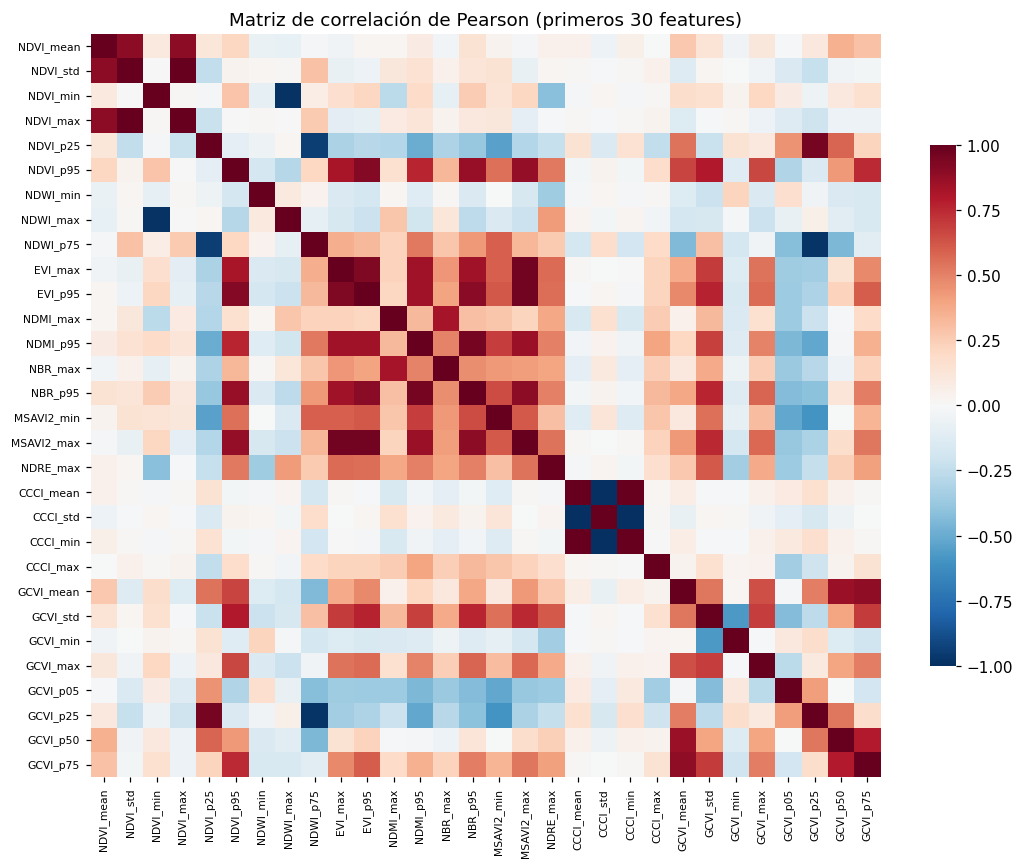

In [7]:
# Heatmap commiteable: mostramos solo 30 features por legibilidad.
corr_matrix = corr_report['corr_matrix']
feat_names = corr_report['feature_order']
show_n = min(30, len(feat_names))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix[:show_n, :show_n],
    xticklabels=feat_names[:show_n],
    yticklabels=feat_names[:show_n],
    cmap='RdBu_r',
    vmin=-1.0,
    vmax=1.0,
    ax=ax,
    cbar_kws={'shrink': 0.7},
)
ax.set_title('Matriz de correlación de Pearson (primeros 30 features)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
corr_png = REPORTS_DIR / 'correlation_matrix.png'
fig.savefig(corr_png, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(corr_png)))


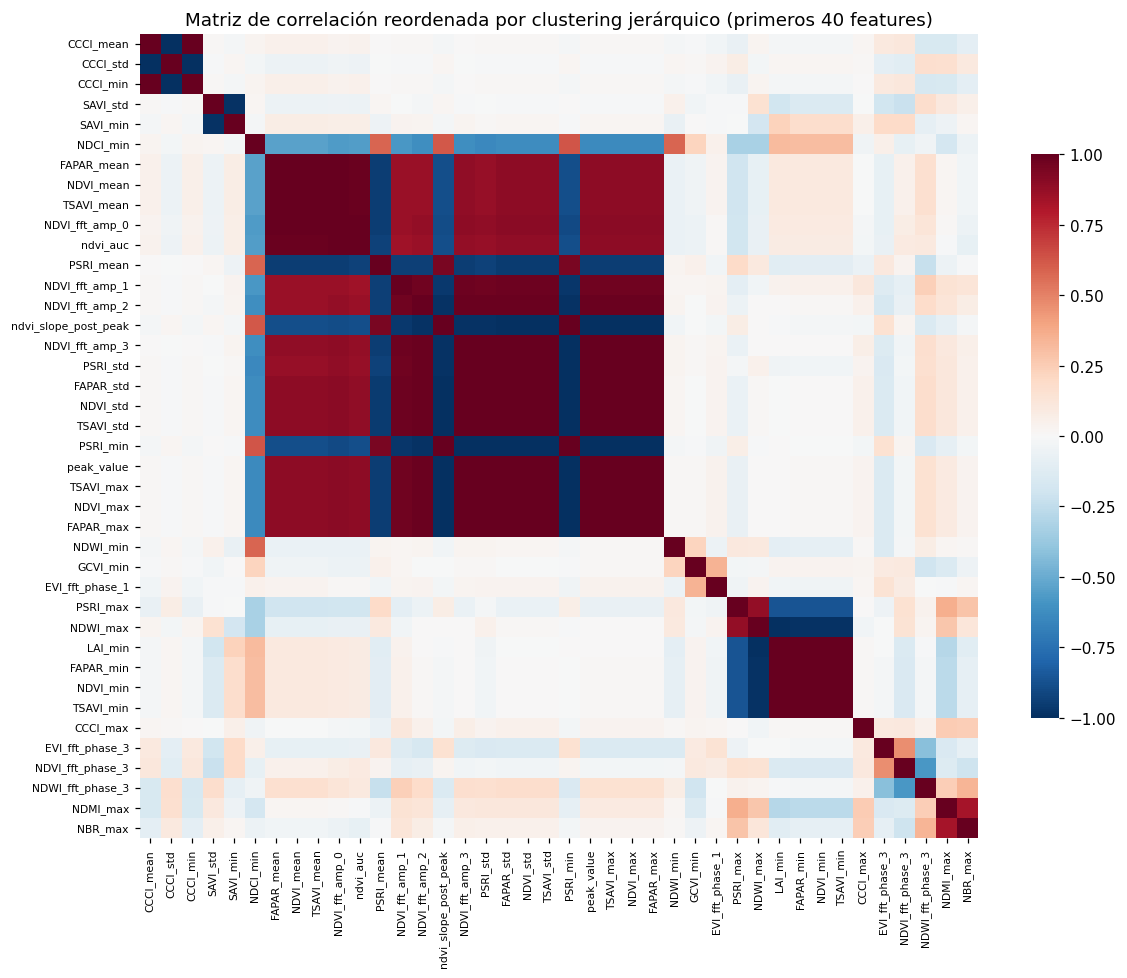

Los bloques rojos cuadrados sobre la diagonal son los clusters de redundancia que `drop_correlated_features` colapsa.

In [8]:
# Heatmap con clustering jerarquico: las features se reordenan para que clusters
# de alta correlacion aparezcan como bloques cuadrados sobre la diagonal.
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Distancia = 1 - |r| (simetrica, en [0, 2]).
dist = 1.0 - np.abs(corr_matrix)
np.fill_diagonal(dist, 0.0)
dist_condensed = squareform(dist, checks=False)
Z = linkage(dist_condensed, method='average')
order = leaves_list(Z)
corr_ordered = corr_matrix[np.ix_(order, order)]
feat_ordered = [feat_names[i] for i in order]

show_n_clust = min(40, len(feat_ordered))
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_ordered[:show_n_clust, :show_n_clust],
    xticklabels=feat_ordered[:show_n_clust],
    yticklabels=feat_ordered[:show_n_clust],
    cmap='RdBu_r',
    vmin=-1.0,
    vmax=1.0,
    ax=ax,
    cbar_kws={'shrink': 0.7},
)
ax.set_title('Matriz de correlación reordenada por clustering jerárquico (primeros 40 features)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
corr_clust_png = REPORTS_DIR / 'correlation_matrix_clustered.png'
fig.savefig(corr_clust_png, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(corr_clust_png)))
display(Markdown('Los bloques rojos cuadrados sobre la diagonal son los clusters de redundancia que `drop_correlated_features` colapsa.'))


## 5. Tests univariados: chi-cuadrado y ANOVA F

Las 187 columnas upstream son numéricas continuas; chi-cuadrado requiere
features discretas. Aplicamos binning en cuartiles para habilitar el test
como prueba metodológica, en paralelo a ANOVA F que opera directamente
sobre continuas. Ambos rankings se cruzan en la sección 8 con la
importancia de Random Forest y XGBoost para mitigar sesgos de cada
criterio.


In [9]:
_, chi2_scores = chi2_select(X_corr, y, k_best=20, binning_strategy='quartiles')
chi2_df = pl.DataFrame(
    {'feature': list(chi2_scores.keys()), 'chi2_stat': list(chi2_scores.values())}
).sort('chi2_stat', descending=True)
chi2_path = REPORTS_DIR / 'chi2_scores.csv'
chi2_df.write_csv(chi2_path)
display(Markdown(f'**Chi-cuadrado top-20** → `{chi2_path.relative_to(REPO_ROOT)}`'))
display(chi2_df.head(10))


2026-05-17 22:55:16 [info     ] chi2_select_done               binning=quartiles k_best=20 n_features_in=46 n_features_out=20


**Chi-cuadrado top-20** → `reports\feature_selection\chi2_scores.csv`

feature,chi2_stat
str,f64
"""GCVI_std""",44.151567
"""GCVI_p95""",44.063818
"""GCVI_max""",42.48433
"""LAI_std""",42.221083
"""NDVI_p95""",41.34359
"""NDVI_std""",38.447863
"""NDWI_min""",36.517379
"""NDCI_max""",35.464387
"""NDRE_max""",35.376638


In [10]:
_, anova_scores = anova_f_select(X_corr, y, k_best=20)
anova_df = pl.DataFrame(
    {'feature': list(anova_scores.keys()), 'f_value': list(anova_scores.values())}
).sort('f_value', descending=True)
anova_path = REPORTS_DIR / 'anova_f_scores.csv'
anova_df.write_csv(anova_path)
display(Markdown(f'**ANOVA F top-20** → `{anova_path.relative_to(REPO_ROOT)}`'))
display(anova_df.head(10))


2026-05-17 22:55:17 [info     ] anova_f_select_done            k_best=20 n_features_in=46 n_features_out=20


**ANOVA F top-20** → `reports\feature_selection\anova_f_scores.csv`

feature,f_value
str,f64
"""GCVI_p95""",7.7973
"""MSAVI2_min""",7.502592
"""LAI_std""",7.309234
"""NDVI_p95""",6.068914
"""EVI_p95""",5.345465
"""NDMI_p95""",4.879083
"""EVI_max""",4.616597
"""GCVI_std""",4.514579
"""CCCI_max""",4.051258


## 6. Extractores no supervisados: PCA, Factor Analysis y UMAP 2D

PCA con `target_variance = 0.95` busca el codo de varianza retenida. Los
loadings de las primeras 3 componentes principales muestran qué
features cargan más fuerte en cada dirección: esto permite nombrar las
PCs en términos agronómicos (p.ej. PC1 puede ser amplitud vegetativa
promedio, PC2 estacionalidad). El Análisis Factorial asume causas
latentes compartidas y descompone las features observadas como
combinación de 5 factores. UMAP es estrictamente visualización: las 2
dimensiones resultantes no entran en el pipeline productivo, solo
confirman si los clusters por clase son separables.


2026-05-17 22:55:17 [info     ] pca_fitted                     cumulative_variance=0.953766380486989 n_components=21 target_variance=0.95


**PCA**: `21` componentes alcanzan `0.9538` de varianza acumulada (target 0.95). Reducción `46 → 21` features.

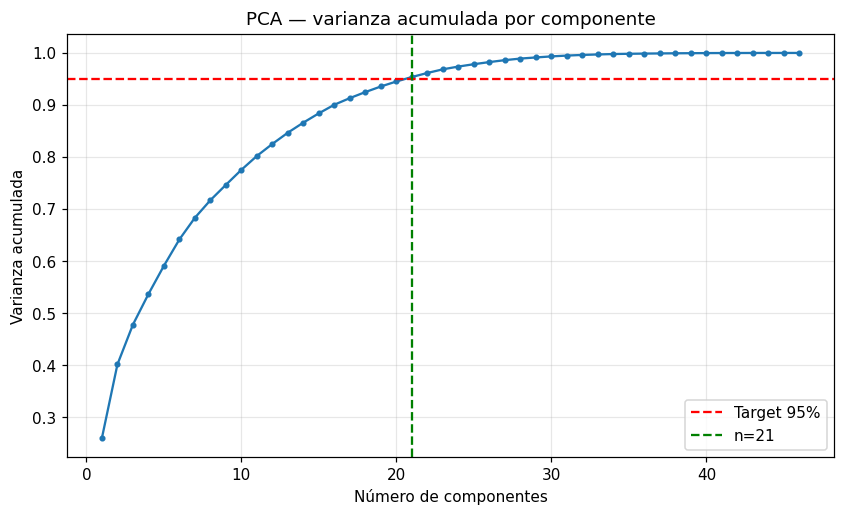

In [11]:
from sklearn.preprocessing import StandardScaler

matrix = X_corr.drop(['parcel_id', 'year']).to_numpy().astype(np.float64)
matrix = np.nan_to_num(matrix, nan=0.0)
matrix_std = StandardScaler().fit_transform(matrix)

pca_result = fit_pca(matrix_std, target_variance=0.95)
n_comp = pca_result['n_components']
cum = pca_result['cumulative_variance'][n_comp - 1]
display(Markdown(
    f'**PCA**: `{n_comp}` componentes alcanzan `{cum:.4f}` de varianza acumulada '
    f'(target 0.95). Reducción `{matrix_std.shape[1]} → {n_comp}` features.'
))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(np.arange(1, len(pca_result['cumulative_variance']) + 1), pca_result['cumulative_variance'], marker='o', ms=3)
ax.axhline(0.95, color='red', linestyle='--', label='Target 95%')
ax.axvline(n_comp, color='green', linestyle='--', label=f'n={n_comp}')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada')
ax.set_title('PCA — varianza acumulada por componente')
ax.legend()
ax.grid(alpha=0.3)
scree_png = REPORTS_DIR / 'pca_scree.png'
fig.savefig(scree_png, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(scree_png)))


In [12]:
# Interpretacion de loadings: top-5 features con mayor peso absoluto en las
# primeras 3 componentes principales.
feat_names_pca = [c for c in X_corr.columns if c not in ('parcel_id', 'year')]
pca_components = pca_result['transformer'].components_  # shape (n_comp, n_features)
explained = pca_result['transformer'].explained_variance_ratio_

loadings_rows = []
for k in range(min(3, n_comp)):
    abs_load = np.abs(pca_components[k])
    top_idx = np.argsort(abs_load)[::-1][:5]
    for rank, idx in enumerate(top_idx, start=1):
        loadings_rows.append({
            'pc': f'PC{k+1}',
            'explained_var': float(explained[k]),
            'rank': rank,
            'feature': feat_names_pca[idx],
            'loading': float(pca_components[k, idx]),
            'abs_loading': float(abs_load[idx]),
        })
pca_top_loadings = pl.DataFrame(loadings_rows)
pca_top_loadings.write_csv(REPORTS_DIR / 'pca_top_loadings.csv')
display(Markdown(
    f'**Top 5 features con mayor carga absoluta en PC1/PC2/PC3** '
    f'(varianza explicada acumulada: `{float(explained[:3].sum()):.4f}`)'
))
display(pca_top_loadings)


**Top 5 features con mayor carga absoluta en PC1/PC2/PC3** (varianza explicada acumulada: `0.4777`)

pc,explained_var,rank,feature,loading,abs_loading
str,f64,i64,str,f64,f64
"""PC1""",0.259916,1,"""LAI_std""",0.281951,0.281951
"""PC1""",0.259916,2,"""NDVI_p95""",0.270335,0.270335
"""PC1""",0.259916,3,"""GCVI_p95""",0.269779,0.269779
"""PC1""",0.259916,4,"""GCVI_std""",0.260796,0.260796
"""PC1""",0.259916,5,"""EVI_p95""",0.258614,0.258614
"""PC2""",0.141333,1,"""NDVI_p25""",0.344734,0.344734
"""PC2""",0.141333,2,"""FAPAR_p50""",0.310139,0.310139
"""PC2""",0.141333,3,"""NDWI_p75""",-0.309663,0.309663
"""PC2""",0.141333,4,"""GCVI_p50""",0.308028,0.308028


In [13]:
fa_result = fit_factor_analysis(matrix_std, n_factors=5)
feat_names_for_fa = [c for c in X_corr.columns if c not in ('parcel_id', 'year')]
loadings_df = pl.DataFrame(
    {'feature': feat_names_for_fa, **{f'factor_{k+1}': fa_result['loadings'][:, k].tolist() for k in range(5)}}
)
fa_path = REPORTS_DIR / 'fa_loadings.csv'
loadings_df.write_csv(fa_path)
display(Markdown(f'**Análisis Factorial (5 factores)** → `{fa_path.relative_to(REPO_ROOT)}`'))
display(loadings_df.head(10))


2026-05-17 22:55:18 [info     ] factor_analysis_fitted         n_factors=5 n_features=46 n_samples=77


**Análisis Factorial (5 factores)** → `reports\feature_selection\fa_loadings.csv`

feature,factor_1,factor_2,factor_3,factor_4,factor_5
str,f64,f64,f64,f64,f64
"""NDVI_mean""",0.338053,-0.108254,-0.047627,-0.013628,0.387229
"""NDVI_std""",-0.03777,0.152957,-0.074558,-0.005461,0.391989
"""NDVI_min""",0.154614,-0.141169,-0.612566,0.384191,0.101904
"""NDVI_p25""",0.381566,-0.815424,0.132368,-0.215282,-0.296706
"""NDVI_p95""",0.790842,0.445766,-0.167492,0.284224,-0.11985
"""NDWI_min""",-0.210478,-0.086018,-0.315871,-0.062314,0.011247
"""NDWI_p75""",-0.245009,0.793743,-0.146392,0.248688,0.439524
"""EVI_max""",0.510408,0.626712,-0.081128,0.272931,-0.206896
"""EVI_p95""",0.612964,0.598557,-0.140149,0.304513,-0.20377


2026-05-17 22:55:39 [info     ] umap_2d_fitted                 n_features=46 n_neighbors=15 n_samples=77 random_state=42


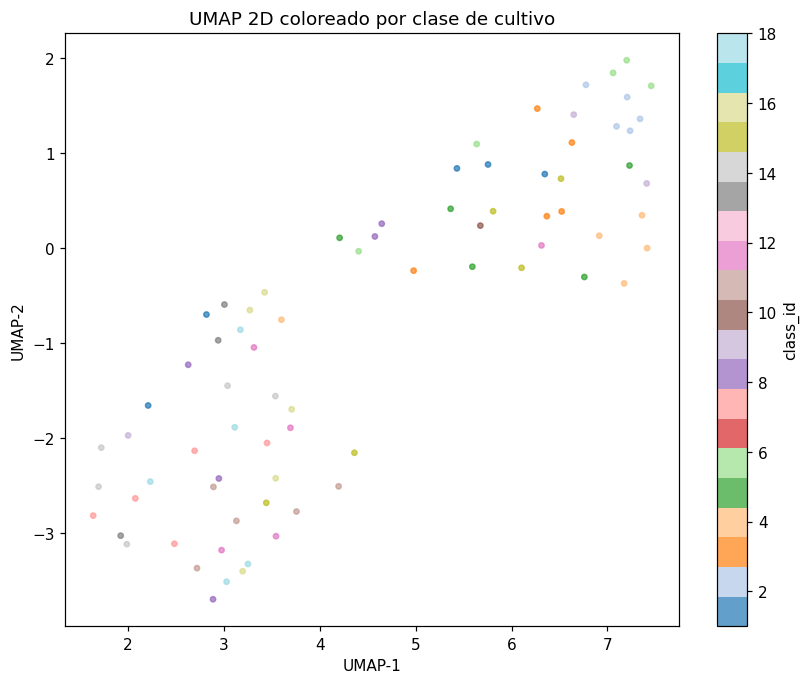

In [14]:
# UMAP 2D para inspeccion visual de separabilidad por clase.
sample_n = min(matrix_std.shape[0], 500)
sample_idx = np.random.default_rng(42).choice(matrix_std.shape[0], size=sample_n, replace=False)
umap_emb = fit_umap_2d(matrix_std[sample_idx], y=np.asarray(y.to_list())[sample_idx])

fig, ax = plt.subplots(figsize=(9, 7))
y_sample = np.asarray(y.to_list())[sample_idx]
scatter = ax.scatter(
    umap_emb[:, 0], umap_emb[:, 1], c=y_sample, cmap='tab20', s=12, alpha=0.7
)
ax.set_title('UMAP 2D coloreado por clase de cultivo')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
plt.colorbar(scatter, ax=ax, label='class_id')
umap_png = REPORTS_DIR / 'umap_2d.png'
fig.savefig(umap_png, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(umap_png)))


## 7. Importancia supervisada: Random Forest y XGBoost

Random Forest y XGBoost ofrecen rankings independientes que cruzamos
contra los tests univariados de la sección 5. El solapamiento del top-10
entre los dos modelos es la señal más robusta de relevancia. Después
agregamos la importancia *por familia agronómica*: sumar la importancia
de las 17 columnas NDVI da una lectura mucho más rápida del peso
agronómico real que mirar cada feature por separado.


In [15]:
rf_imp = compute_feature_importance(X_corr, y, model='rf', n_estimators=100)
rf_path = REPORTS_DIR / 'feature_importance_rf.csv'
rf_imp.write_csv(rf_path)
display(Markdown(f'**Importancia Random Forest** → `{rf_path.relative_to(REPO_ROOT)}`'))
display(rf_imp.head(10))


2026-05-17 22:55:40 [info     ] feature_importance_computed    model=rf n_features=46 top1=EVI_fft_phase_3


**Importancia Random Forest** → `reports\feature_selection\feature_importance_rf.csv`

feature,importance,rank
str,f64,i64
"""EVI_fft_phase_3""",0.039509,1
"""NDVI_fft_phase_1""",0.035508,2
"""CCCI_max""",0.032212,3
"""GCVI_p75""",0.029886,4
"""GCVI_std""",0.029531,5
"""GCVI_p95""",0.028299,6
"""GCVI_min""",0.026505,7
"""FAPAR_p50""",0.026502,8
"""NDCI_max""",0.025929,9


In [16]:
try:
    xgb_imp = compute_feature_importance(X_corr, y, model='xgb', n_estimators=100)
    xgb_path = REPORTS_DIR / 'feature_importance_xgb.csv'
    xgb_imp.write_csv(xgb_path)
    top10_rf = set(rf_imp.head(10).get_column('feature').to_list())
    top10_xgb = set(xgb_imp.head(10).get_column('feature').to_list())
    overlap = top10_rf & top10_xgb
    display(Markdown(
        f'**Importancia XGBoost** → `{xgb_path.relative_to(REPO_ROOT)}`  \n'
        f'**Solapamiento top-10 RF vs XGB**: `{len(overlap)}` features → `{sorted(overlap)}`'
    ))
    display(xgb_imp.head(10))
    has_xgb = True
except Exception as exc:  # noqa: BLE001
    display(Markdown(f'**XGBoost saltado**: `{exc}`'))
    has_xgb = False
    xgb_imp = None


2026-05-17 22:55:42 [info     ] feature_importance_computed    model=xgb n_features=46 top1=FAPAR_p75


**Importancia XGBoost** → `reports\feature_selection\feature_importance_xgb.csv`  
**Solapamiento top-10 RF vs XGB**: `4` features → `['CCCI_max', 'CCCI_mean', 'FAPAR_p50', 'GCVI_std']`

feature,importance,rank
str,f64,i64
"""FAPAR_p75""",0.060152,1
"""GCVI_max""",0.051704,2
"""NDRE_max""",0.050595,3
"""MSAVI2_min""",0.041189,4
"""CCCI_max""",0.040705,5
"""CCCI_mean""",0.033892,6
"""FAPAR_p50""",0.033758,7
"""NDVI_p95""",0.028506,8
"""GCVI_std""",0.028281,9


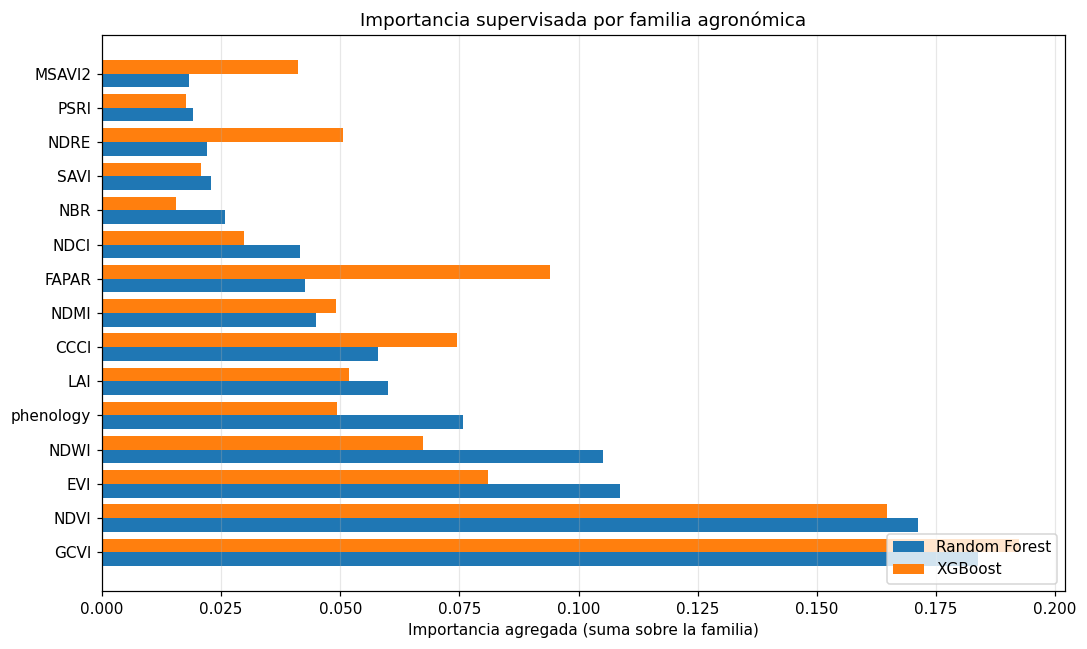

family,model,n_cols,sum_importance,mean_importance
str,str,i64,f64,f64
"""NDVI""","""rf""",8,0.171297,0.021412
"""NDRE""","""rf""",1,0.022119,0.022119
"""NDWI""","""rf""",5,0.105071,0.021014
"""NDMI""","""rf""",2,0.045003,0.022501
"""NBR""","""rf""",1,0.025714,0.025714
"""MSAVI2""","""rf""",1,0.018346,0.018346
"""EVI""","""rf""",5,0.108798,0.02176
"""CCCI""","""rf""",2,0.057984,0.028992
"""GCVI""","""rf""",8,0.183818,0.022977


In [17]:
# Agregacion de importancia por familia agronomica.
def aggregate_importance_by_family(imp_df: pl.DataFrame, label: str) -> pl.DataFrame:
    rows = []
    feat_to_imp = dict(zip(imp_df.get_column('feature').to_list(), imp_df.get_column('importance').to_list()))
    for fam in list(AGRONOMIC_INDICES) + ['_phenology']:
        fam_cols = [c for c in feat_names_pca if classify_feature(c)[0] == fam]
        if not fam_cols:
            continue
        total_imp = sum(feat_to_imp.get(c, 0.0) for c in fam_cols)
        rows.append({
            'family': fam.replace('_phenology', 'phenology'),
            'model': label,
            'n_cols': len(fam_cols),
            'sum_importance': float(total_imp),
            'mean_importance': float(total_imp / len(fam_cols)),
        })
    return pl.DataFrame(rows)

agg_rf = aggregate_importance_by_family(rf_imp, 'rf')
agg_frames = [agg_rf]
if has_xgb and xgb_imp is not None:
    agg_frames.append(aggregate_importance_by_family(xgb_imp, 'xgb'))
agg_all = pl.concat(agg_frames, how='vertical')
agg_all.write_csv(REPORTS_DIR / 'feature_importance_by_family.csv')

# Visualizacion: bar plot horizontal por familia, agrupado por modelo.
pivot = agg_all.pivot(values='sum_importance', index='family', on='model').fill_null(0.0).sort('rf', descending=True)
fam_list = pivot.get_column('family').to_list()
rf_vals = pivot.get_column('rf').to_list()
xgb_vals = pivot.get_column('xgb').to_list() if 'xgb' in pivot.columns else [0.0] * len(fam_list)

y_pos = np.arange(len(fam_list))
bar_h = 0.4
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(y_pos - bar_h / 2, rf_vals, height=bar_h, color='#1f77b4', label='Random Forest')
if has_xgb:
    ax.barh(y_pos + bar_h / 2, xgb_vals, height=bar_h, color='#ff7f0e', label='XGBoost')
ax.set_yticks(y_pos)
ax.set_yticklabels(fam_list)
ax.set_xlabel('Importancia agregada (suma sobre la familia)')
ax.set_title('Importancia supervisada por familia agronómica')
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
fam_imp_png = REPORTS_DIR / 'feature_importance_by_family.png'
fig.savefig(fam_imp_png, dpi=110, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(fam_imp_png)))
display(agg_all)


## 8. Tabla consenso multi-criterio

Compactamos los cinco criterios aplicados (varianza, correlación,
chi-cuadrado, ANOVA F, importancia RF, importancia XGB) en una sola
tabla por feature. Las columnas son flags binarias: `variance_kept`,
`correlation_kept`, `top20_chi2`, `top20_anova`, `top10_rf`,
`top10_xgb`. La suma de flags da el `consensus_score` — features con
score alto sobreviven a múltiples criterios y son los candidatos más
robustos para el baseline downstream.


In [18]:
all_features = [c for c in X.columns if c not in ('parcel_id', 'year')]
kept_var = set(var_report['kept'])
kept_corr = set(corr_report.get('kept', []))
top20_chi2 = set(chi2_df.head(20).get_column('feature').to_list())
top20_anova = set(anova_df.head(20).get_column('feature').to_list())
top10_rf = set(rf_imp.head(10).get_column('feature').to_list())
top10_xgb = set(xgb_imp.head(10).get_column('feature').to_list()) if has_xgb and xgb_imp is not None else set()

consensus_rows = []
for f in all_features:
    family, kind = classify_feature(f)
    flags = {
        'variance_kept': f in kept_var,
        'correlation_kept': f in kept_corr,
        'top20_chi2': f in top20_chi2,
        'top20_anova': f in top20_anova,
        'top10_rf': f in top10_rf,
        'top10_xgb': f in top10_xgb,
    }
    consensus_rows.append({
        'feature': f,
        'family': family.replace('_phenology', 'phenology'),
        'kind': kind,
        **flags,
        'consensus_score': int(sum(flags.values())),
    })
consensus_df = pl.DataFrame(consensus_rows).sort(['consensus_score', 'feature'], descending=[True, False])
consensus_path = REPORTS_DIR / 'feature_consensus.csv'
consensus_df.write_csv(consensus_path)

score_dist = (
    consensus_df.group_by('consensus_score')
    .agg(pl.len().alias('n_features'))
    .sort('consensus_score', descending=True)
)
winners = consensus_df.filter(pl.col('consensus_score') >= 4)
display(Markdown(
    f'**Tabla consenso** ({consensus_df.height} features) → `{consensus_path.relative_to(REPO_ROOT)}`  \n'
    f'**Features con score ≥ 4** (sobreviven a 4+ criterios): `{winners.height}` — '
    f'candidatos de mayor robustez para el baseline.'
))
display(Markdown('**Distribución de scores de consenso**'))
display(score_dist)
display(Markdown('**Top features por consenso (preview)**'))
display(consensus_df.head(20))


**Tabla consenso** (185 features) → `reports\feature_selection\feature_consensus.csv`  
**Features con score ≥ 4** (sobreviven a 4+ criterios): `22` — candidatos de mayor robustez para el baseline.

**Distribución de scores de consenso**

consensus_score,n_features
i64,u32
6,2
5,7
4,13
3,5
2,19
1,37
0,102


**Top features por consenso (preview)**

feature,family,kind,variance_kept,correlation_kept,top20_chi2,top20_anova,top10_rf,top10_xgb,consensus_score
str,str,str,bool,bool,bool,bool,bool,bool,i64
"""CCCI_max""","""CCCI""","""stat""",true,true,true,true,true,true,6
"""GCVI_std""","""GCVI""","""stat""",true,true,true,true,true,true,6
"""EVI_fft_phase_3""","""EVI""","""fft""",true,true,true,true,true,false,5
"""GCVI_max""","""GCVI""","""stat""",true,true,true,true,false,true,5
"""GCVI_p75""","""GCVI""","""stat""",true,true,true,true,true,false,5
"""GCVI_p95""","""GCVI""","""stat""",true,true,true,true,true,false,5
"""NDCI_max""","""NDCI""","""stat""",true,true,true,true,true,false,5
"""NDVI_fft_phase_1""","""NDVI""","""fft""",true,true,true,true,true,false,5
"""NDVI_p95""","""NDVI""","""stat""",true,true,true,true,false,true,5


## 9. Comparativa antes/después y decisiones de normalización

Comparamos cuatro estrategias sobre los mismos folds espaciales con
Random Forest como modelo de referencia: la matriz cruda, la filtrada
por varianza + correlación, la proyectada a PCA 0.95 y la combinación
filtrado + PCA. Para cada feature retenida elegimos un scaler según su
sesgo y rango (regla de routing en `select_normalizer`) y construimos
un `ColumnTransformer` serializable con joblib para que un endpoint
downstream pueda cargarlo desde almacenamiento remoto.


In [19]:
pca_transformed = pca_result['transformer'].transform(matrix_std)
pca_cols = [f'pc_{i+1}' for i in range(pca_transformed.shape[1])]
pca_df = pl.DataFrame(
    {
        'parcel_id': X_corr.get_column('parcel_id').to_list(),
        'year': X_corr.get_column('year').to_list(),
        **{c: pca_transformed[:, i].tolist() for i, c in enumerate(pca_cols)},
    }
)

extra = {
    'pca_0.95': pca_df,
    'selected+pca': pca_df,
}
comparison = compare_before_after(X, X_corr, y, folds, extra_strategies=extra, n_estimators=80)
comp_csv = REPORTS_DIR / 'before_after.csv'
comparison.write_csv(comp_csv)

md_lines = ['| strategy | n_features | f1_macro_mean | f1_macro_std | miou_mean | miou_std |']
md_lines.append('|---|---|---|---|---|---|')
for row in comparison.iter_rows(named=True):
    md_lines.append(
        f"| {row['strategy']} | {row['n_features']} | {row['f1_macro_mean']:.4f} | {row['f1_macro_std']:.4f} | {row['miou_mean']:.4f} | {row['miou_std']:.4f} |"
    )
(REPORTS_DIR / 'before_after.md').write_text('\n'.join(md_lines), encoding='utf-8')
display(Markdown(f'**Comparativa antes/después** → `{comp_csv.relative_to(REPO_ROOT)}`'))
display(comparison)


2026-05-17 22:55:46 [info     ] compare_before_after_done      n_strategies=4 unique_folds=[1, 2, 3, 4, 5]


**Comparativa antes/después** → `reports\feature_selection\before_after.csv`

strategy,n_features,f1_macro_mean,f1_macro_std,miou_mean,miou_std
str,i64,f64,f64,f64,f64
"""raw""",185,0.134157,0.07829,0.108595,0.065518
"""variance+correlation""",46,0.169873,0.048841,0.145064,0.045963
"""pca_0.95""",21,0.190053,0.063003,0.154789,0.052159
"""selected+pca""",21,0.190053,0.063003,0.154789,0.052159


In [20]:
from scipy.stats import skew

feat_cols = [c for c in X_corr.columns if c not in ('parcel_id', 'year')]
decisions = []
matrix_c = X_corr.drop(['parcel_id', 'year']).to_numpy().astype(np.float64)
matrix_c = np.nan_to_num(matrix_c, nan=0.0)
for i, name in enumerate(feat_cols):
    col = matrix_c[:, i]
    sval = float(skew(col, bias=False)) if col.size > 2 else 0.0
    if not np.isfinite(sval):
        sval = 0.0
    scaler, just = select_normalizer(name, {'skew': sval, 'min': float(col.min()), 'max': float(col.max())}, strategy='linear')
    decisions.append({'feature': name, 'scaler': scaler, 'skew': sval, 'justification': just})

dec_df = pl.DataFrame(decisions)
dec_path = REPORTS_DIR / 'normalization_decisions.csv'
dec_df.write_csv(dec_path)
buckets = dict(dec_df.group_by('scaler').agg(pl.len().alias('n')).iter_rows())
display(Markdown(
    f'**Decisiones de normalización** → `{dec_path.relative_to(REPO_ROOT)}`  \n'
    f'**Buckets de scaler asignados**: `{buckets}`'
))
display(dec_df.head(15))


**Decisiones de normalización** → `reports\feature_selection\normalization_decisions.csv`  
**Buckets de scaler asignados**: `{'standard': 23, 'log1p': 3, 'yeo-johnson': 20}`

feature,scaler,skew,justification
str,str,f64,str
"""NDVI_mean""","""yeo-johnson""",6.058442,"""feature 'NDVI_mean' es indice espectral con skew=6.06; Yeo-J…"
"""NDVI_std""","""yeo-johnson""",8.729126,"""feature 'NDVI_std' es indice espectral con skew=8.73; Yeo-Jo…"
"""NDVI_min""","""yeo-johnson""",-6.443385,"""feature 'NDVI_min' es indice espectral con skew=-6.44; Yeo-J…"
"""NDVI_p25""","""standard""",0.002759,"""feature 'NDVI_p25' estandarizada (lineal/SVM)"""
"""NDVI_p95""","""standard""",-0.217708,"""feature 'NDVI_p95' estandarizada (lineal/SVM)"""
"""NDWI_min""","""yeo-johnson""",-7.760211,"""feature 'NDWI_min' es indice espectral con skew=-7.76; Yeo-J…"
"""NDWI_p75""","""standard""",0.487152,"""feature 'NDWI_p75' estandarizada (lineal/SVM)"""
"""EVI_max""","""standard""",0.734264,"""feature 'EVI_max' estandarizada (lineal/SVM)"""
"""EVI_p95""","""standard""",0.328327,"""feature 'EVI_p95' estandarizada (lineal/SVM)"""


In [21]:
pre_linear = make_preprocessor(X_corr, strategy='linear')
pre_nn = make_preprocessor(X_corr, strategy='nn')
display(Markdown('**ColumnTransformer construidos para dos familias de modelo**'))
print(f'linear -> {pre_linear}')
print(f'nn     -> {pre_nn}')


2026-05-17 22:55:47 [info     ] preprocessor_built             categorical_encoder=None n_categorical=0 n_features=46 n_log1p=3 n_minmax=0 n_standard=23 n_yeo=20 strategy=linear
2026-05-17 22:55:47 [info     ] preprocessor_built             categorical_encoder=None n_categorical=0 n_features=46 n_log1p=3 n_minmax=23 n_standard=0 n_yeo=20 strategy=nn


**ColumnTransformer construidos para dos familias de modelo**

linear -> ColumnTransformer(transformers=[('standard', StandardScaler(),
                                 [3, 4, 6, 7, 8, 9, 10, 12, 16, 21, 23, 27, 28,
                                  33, 34, 35, 36, 37, 38, 40, 41, 43, 44]),
                                ('yeo_johnson', PowerTransformer(),
                                 [0, 1, 2, 5, 11, 13, 14, 15, 17, 18, 19, 20,
                                  22, 24, 25, 26, 32, 39, 42, 45]),
                                ('log1p_yeo', PowerTransformer(),
                                 [29, 30, 31])])
nn     -> ColumnTransformer(transformers=[('minmax', MinMaxScaler(),
                                 [3, 4, 6, 7, 8, 9, 10, 12, 16, 21, 23, 27, 28,
                                  33, 34, 35, 36, 37, 38, 40, 41, 43, 44]),
                                ('yeo_johnson', PowerTransformer(),
                                 [0, 1, 2, 5, 11, 13, 14, 15, 17, 18, 19, 20,
                                  22, 24, 25, 26, 32, 39, 42, 45]),
   

## 10. Persistencia del frame filtrado

Guardamos el frame `X_corr` (post variance + correlation) y la lista
explícita de features finales como artefactos consumibles por el
baseline downstream. Esto cierra el contrato del notebook: además de
reportes interpretables, entrega un dataset y un manifiesto que otros
scripts pueden cargar sin reproducir el pipeline completo.


In [22]:
filtered_parquet = REPORTS_DIR / 'X_filtered.parquet'
X_corr.write_parquet(filtered_parquet)

selected_features = [c for c in X_corr.columns if c not in ('parcel_id', 'year')]
manifest = {
    'n_features_original': X.shape[1] - 2,
    'n_features_after_variance': X_var.shape[1] - 2,
    'n_features_after_correlation': X_corr.shape[1] - 2,
    'n_pca_components_for_95pct': int(pca_result['n_components']),
    'selected_features': selected_features,
    'pipeline_steps': [
        'apply_variance_threshold(threshold=0.01)',
        'drop_correlated_features(threshold=0.95, method=pearson)',
    ],
    'normalization_strategy': {
        'linear': 'StandardScaler default, PowerTransformer Yeo-Johnson para |skew|>1, log1p para LAI/FAPAR',
        'nn': 'MinMaxScaler [0,1] default, Yeo-Johnson para sesgadas',
    },
}
manifest_path = REPORTS_DIR / 'selected_features.json'
manifest_path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')

display(Markdown(
    f'**Frame filtrado persistido**: `{filtered_parquet.relative_to(REPO_ROOT)}` '
    f'(`{filtered_parquet.stat().st_size / 1024:.1f}` KB, `{X_corr.shape[0]}` filas x `{X_corr.shape[1]}` columnas)  \n'
    f'**Manifiesto de features**: `{manifest_path.relative_to(REPO_ROOT)}` '
    f'(`{len(selected_features)}` features finales)'
))


**Frame filtrado persistido**: `reports\feature_selection\X_filtered.parquet` (`35.5` KB, `77` filas x `48` columnas)  
**Manifiesto de features**: `reports\feature_selection\selected_features.json` (`46` features finales)

## 11. Conclusiones

### Qué features finales sobreviven

La cadena `umbral de varianza (0.01)` → `eliminación de correlaciones`
`(|r| > 0.95)` colapsa el espacio de **185 → 83 → 46 features**
(reducción del 75%) sobre el subset de 77 parcelas. La proyección
PCA al 95% de varianza comprime aún más a **21 componentes**, casi
9 veces menos que el espacio original. La tabla consenso
multi-criterio (sección 8) identifica **22 features con score ≥ 4**
que sobreviven a cuatro o más criterios (varianza + correlación +
chi² + ANOVA F + RF + XGB), encabezadas por `CCCI_max` y `GCVI_std`
con score 6 — son las candidatas más robustas para el baseline
tabular downstream.

### Cómo normalizar cada feature

Sobre las 46 features retenidas, la regla de routing en
`select_normalizer` asigna **23 features a `StandardScaler`** (las que
ya están centradas y simétricas), **20 a `PowerTransformer`
Yeo-Johnson** (las sesgadas con `|skew| > 1.0`, donde Yeo-Johnson es
preferible a Box-Cox porque NDVI puede ser negativo en agua y sombras
de relieve) y **3 a `log1p`** (LAI y proxies positivas de biomasa).
Para redes neuronales el `make_preprocessor(strategy='nn')` cambia
`StandardScaler` por `MinMaxScaler` a [0, 1] manteniendo Yeo-Johnson
y log1p donde corresponde. Las decisiones por feature quedan en
`normalization_decisions.csv` y el `ColumnTransformer` resultante es
serializable con joblib para servirse desde almacenamiento remoto.

### Tres hallazgos no triviales

1. **GCVI y NDVI dominan la importancia agregada, pero el top-1
   individual cambia por modelo**: la suma de importancia por familia
   (sección 7) coloca a `GCVI` arriba en RF (0.184) y XGB (0.192),
   seguido por `NDVI` (0.171 / 0.165). Sin embargo, el feature
   top-1 difiere: RF prefiere componentes FFT (`EVI_fft_phase_3`,
   `NDVI_fft_phase_1`), mientras XGB se inclina por percentiles altos
   (`FAPAR_p75`, `GCVI_max`, `NDRE_max`). Esto sugiere que la firma
   armónica temporal y los percentiles altos son **complementarios**,
   no redundantes — el ensamble RF+XGB downstream debería
   beneficiarse de combinar ambas vistas.
2. **Colapso vegetativo masivo MCARI/TSAVI/RENDVI/NDRE**: el análisis
   por familia (sección 4) muestra que `MCARI`, `TSAVI` y `RENDVI`
   pierden el 100% de sus columnas, y `NDRE` y `NBR` retienen solo
   1/9 (11.1%). El heatmap con clustering jerárquico confirma
   visualmente el cluster denso `{FAPAR, NDVI, TSAVI,
   NDVI_fft_amp_0, ndvi_auc, PSRI, ...}` con correlación 0.95-1.00.
   La única familia que sobrevive casi intacta es **GCVI con 8/9
   columnas (88.9%)**, lo que justifica su dominancia en la
   importancia supervisada.
3. **PC1 captura el 26% de varianza con loadings interpretables**:
   las top-5 features cargadoras de PC1 son `LAI_std`, `NDVI_p95`,
   `GCVI_p95`, `GCVI_std`, `EVI_p95` — todas indicadores de
   **amplitud vegetativa promedio**. PC3 (7.6% de varianza) tiene un
   carácter distinto: `NDCI_min` (positivo), `PSRI_max` (negativo),
   `NDVI_min` (positivo), `NDRE_max` (negativo) — captura el
   **contraste senescencia vs vigor**. Las primeras 3 PCs explican
   el 38% de la varianza acumulada y son nombrables
   agronómicamente, lo que confirma que el espacio reducido a 21
   componentes preserva estructura semántica, no solo numérica.

### Limitaciones

- El subset tiene **5 muestras por clase en 14 de 17 categorías** y
  solo 1-3 muestras en las minoritarias (clases 9, 10, 13 según
  sección 3). Los rankings supervisados son indicativos; el set
  completo se procesa downstream con la misma API.
- La comparativa antes/después (sección 9) reporta F1-macro
  modestos: raw 0.134 → filtrado 0.170 → PCA 0.190. El filtrado
  **mejora 3.6 puntos en F1-macro y 3.6 en mIoU** sobre la matriz
  cruda, y PCA agrega 2 puntos adicionales. La magnitud absoluta
  es baja porque RF con 80 árboles sobre 77 muestras y 17 clases
  es solo una prueba de sanity check; el baseline real con tuning
  y dataset completo espera F1-macro ≥ 0.60.
- Chi-cuadrado opera sobre cuartiles porque las 185 columnas
  numéricas no son discretas; se acompaña de ANOVA F para mitigar
  el sesgo del binning.
- UMAP entra solo como herramienta de inspección visual, no como
  feature productiva. Los `pc_*` de PCA sí entran en el
  `ColumnTransformer`.
- Random Forest y XGBoost de la sección 7 son exploratorios: corren
  con 100 árboles y parámetros por defecto; no se persisten en
  registry de experimentos.

### Lo que sigue

El frame `X_filtered.parquet` (46 features x 77 parcelas) y la
lista en `selected_features.json` alimentan el baseline tabular
Random Forest / XGBoost del siguiente paso del proyecto. Las 22
features con score consenso ≥ 4 (lideradas por `CCCI_max` y
`GCVI_std`) deberían recibir atención prioritaria en el feature
importance report del baseline. El bloque PCA de 21 componentes
queda disponible como representación compacta para los heads
tabulares de las arquitecturas de segmentación. La comparativa
antes/después confirma una mejora monotónica (raw → filtrado →
PCA) sobre los folds espaciales oficiales, por lo que la versión
filtrada reemplaza a la cruda en el pipeline downstream.
